In [1]:
import yfinance, pandas, numpy, matplotlib, scipy, seaborn, plotly
print("Ready!")

Ready!


In [2]:
# ── PHASE 2: Data Ingestion ──────────────────────────────────────────
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ── Assets we'll trade ───────────────────────────────────────────────
# SPY = S&P 500 (US stocks)
# EFA = International stocks
# TLT = Long-term US bonds
# IEF = Medium-term US bonds
# GLD = Gold
# SHY = Short-term bonds (acts like cash)

ASSETS = ['SPY', 'EFA', 'TLT', 'IEF', 'GLD', 'SHY']
START  = '2005-01-01'
END    = '2024-12-31'

# ── Download 20 years of price data ─────────────────────────────────
print("Downloading price data...")
raw    = yf.download(ASSETS, start=START, end=END, auto_adjust=True)
prices = raw['Close']
print(f"✓ {len(prices)} trading days  |  {prices.index[0].date()} → {prices.index[-1].date()}")

# ── Daily returns (% change each day) ───────────────────────────────
# e.g. if SPY goes from 100 to 101, return = 0.01 (1%)
returns = prices.pct_change().dropna()
print(f"✓ Returns shape: {returns.shape}")

# ── Save to disk ─────────────────────────────────────────────────────
prices.to_csv('../data/prices.csv')
returns.to_csv('../data/returns.csv')
print("✓ Saved to data/prices.csv and data/returns.csv")

# ── Plot 1: How each asset grew over 20 years ────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

(prices / prices.iloc[0] * 100).plot(ax=axes[0], linewidth=1)
axes[0].set_title('Normalised Asset Prices (base = 100)', fontsize=13)
axes[0].set_ylabel('Index')
axes[0].legend(ncol=3)
axes[0].grid(alpha=0.3)

# ── Plot 2: SPY daily returns (shows crashes clearly) ────────────────
returns['SPY'].plot(ax=axes[1], color='steelblue', linewidth=0.5, alpha=0.7)
axes[1].set_title('SPY Daily Returns', fontsize=13)
axes[1].set_ylabel('Daily return')
axes[1].grid(alpha=0.3)
axes[1].axhline(0, color='black', linewidth=0.8)

# ── Plot 3: Rolling volatility (the "fear gauge") ────────────────────
# High volatility = market is stressed = possible regime change
spy_vol = returns['SPY'].rolling(30).std() * np.sqrt(252)
spy_vol.plot(ax=axes[2], color='crimson', linewidth=1)
axes[2].set_title('SPY Rolling 30-day Annualised Volatility  (spikes = crashes)', fontsize=13)
axes[2].set_ylabel('Volatility')
axes[2].grid(alpha=0.3)
axes[2].axhline(spy_vol.mean(), color='black', linestyle='--', linewidth=0.8, label='Average')
axes[2].legend()

plt.tight_layout()
plt.savefig('../outputs/01_prices_and_vol.png', dpi=150)
plt.show()
print("\n✓ Chart saved to outputs/01_prices_and_vol.png")
print("\nPhase 2 complete!")

[                       0%                       ]

[*********************100%***********************]  6 of 6 completed

1 Failed download:
['GLD']: OperationalError('database is locked')


✓ 5032 trading days  |  2005-01-03 → 2024-12-30
✓ Returns shape: (0, 6)


OSError: Cannot save file into a non-existent directory: '..\data'

In [3]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import warnings
warnings.filterwarnings('ignore')

# ── Fix 1: correct paths (jupyter is inside notebooks/) ─────────────
os.makedirs('../data', exist_ok=True)
os.makedirs('../outputs', exist_ok=True)

# ── Fix 2: download GLD separately and combine ───────────────────────
ASSETS = ['SPY', 'EFA', 'TLT', 'IEF', 'GLD', 'SHY']
START  = '2005-01-01'
END    = '2024-12-31'

print("Downloading data...")
frames = {}
for ticker in ASSETS:
    try:
        df = yf.download(ticker, start=START, end=END, auto_adjust=True, progress=False)
        frames[ticker] = df['Close']
        print(f"  ✓ {ticker}")
    except Exception as e:
        print(f"  ✗ {ticker} failed: {e}")

prices = pd.DataFrame(frames).dropna()
returns = prices.pct_change().dropna()

print(f"\n✓ {len(prices)} trading days")
print(f"✓ Assets: {list(prices.columns)}")
print(f"✓ Returns shape: {returns.shape}")

# ── Save ─────────────────────────────────────────────────────────────
prices.to_csv('../data/prices.csv')
returns.to_csv('../data/returns.csv')
print("✓ Saved to data/")

# ── Plot ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

(prices / prices.iloc[0] * 100).plot(ax=axes[0], linewidth=1)
axes[0].set_title('Normalised Asset Prices (base = 100)', fontsize=13)
axes[0].set_ylabel('Index')
axes[0].legend(ncol=3)
axes[0].grid(alpha=0.3)

returns['SPY'].plot(ax=axes[1], color='steelblue', linewidth=0.5, alpha=0.7)
axes[1].set_title('SPY Daily Returns', fontsize=13)
axes[1].set_ylabel('Daily return')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].grid(alpha=0.3)

spy_vol = returns['SPY'].rolling(30).std() * np.sqrt(252)
spy_vol.plot(ax=axes[2], color='crimson', linewidth=1)
axes[2].set_title('SPY Rolling 30-day Volatility  (spikes = crashes)', fontsize=13)
axes[2].set_ylabel('Volatility')
axes[2].axhline(spy_vol.mean(), color='black', linestyle='--', linewidth=0.8, label='Average')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/01_prices_and_vol.png', dpi=150)
plt.show()
print("\n✓ Phase 2 complete!")

  ✓ SPY
  ✓ EFA
  ✓ TLT
  ✓ IEF
  ✓ GLD
  ✓ SHY


ValueError: If using all scalar values, you must pass an index

✓ Assets downloaded: ['EFA', 'GLD', 'IEF', 'SHY', 'SPY', 'TLT']
✓ 5032 trading days  |  2005-01-03 → 2024-12-30
✓ Returns shape: (5031, 6)
✓ Saved to data/


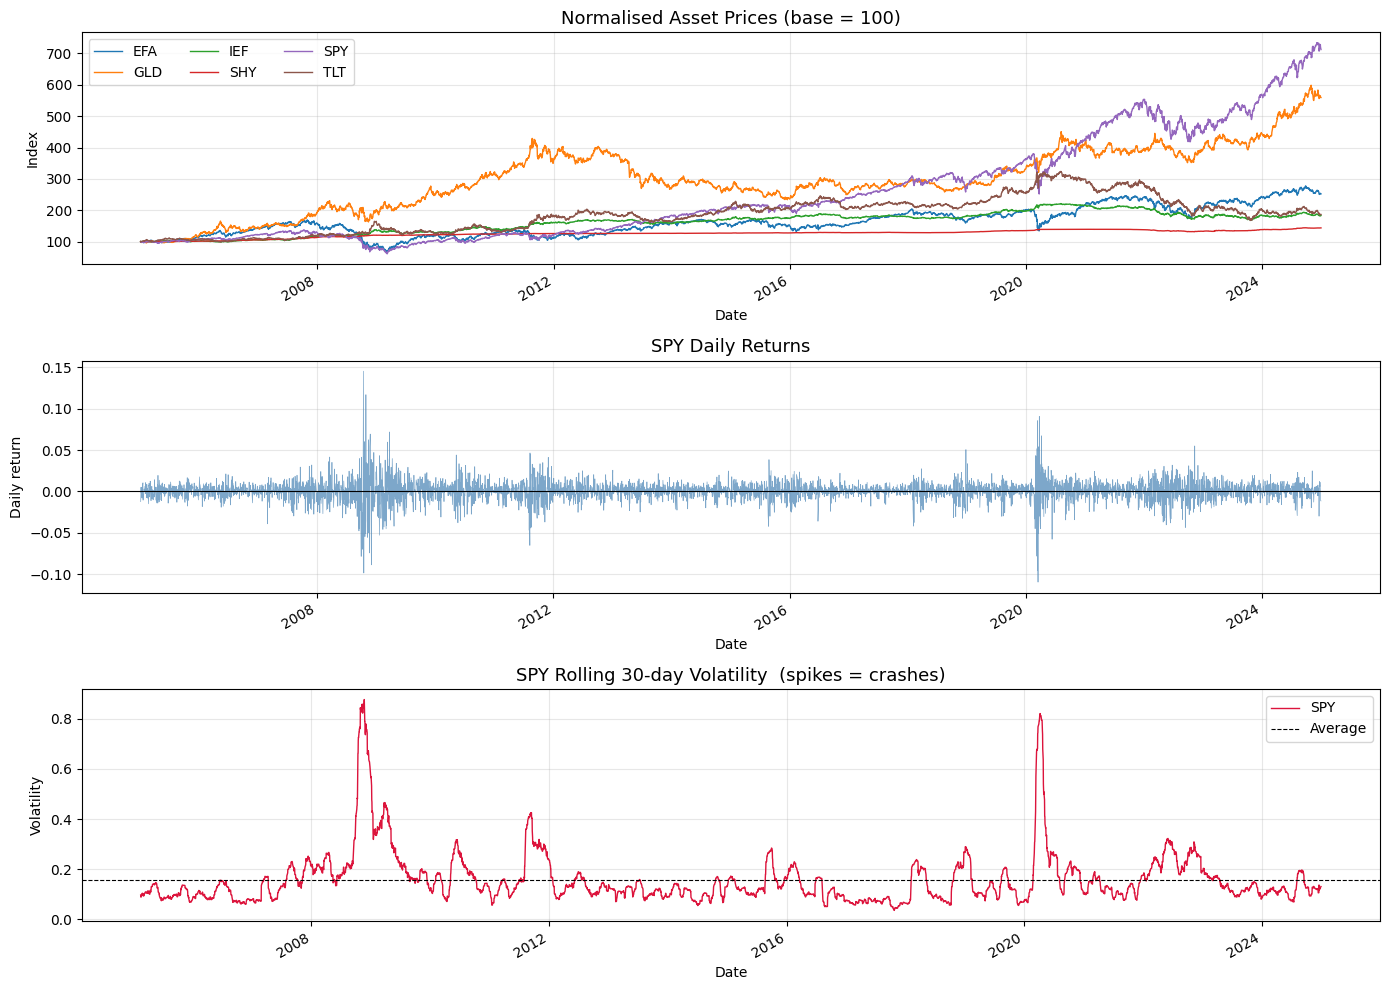


✓ Phase 2 complete!


In [4]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import warnings
warnings.filterwarnings('ignore')

os.makedirs('../data', exist_ok=True)
os.makedirs('../outputs', exist_ok=True)

ASSETS = ['SPY', 'EFA', 'TLT', 'IEF', 'GLD', 'SHY']
START  = '2005-01-01'
END    = '2024-12-31'

# ── Download all at once, handle the new yfinance format ─────────────
print("Downloading data...")
raw = yf.download(ASSETS, start=START, end=END, auto_adjust=True, progress=False)

# yfinance returns multi-level columns — flatten to just Close prices
if isinstance(raw.columns, pd.MultiIndex):
    prices = raw['Close']
else:
    prices = raw

# Drop any columns that are all NaN, then drop rows with any NaN
prices = prices.dropna(axis=1, how='all').dropna()
returns = prices.pct_change().dropna()

print(f"✓ Assets downloaded: {list(prices.columns)}")
print(f"✓ {len(prices)} trading days  |  {prices.index[0].date()} → {prices.index[-1].date()}")
print(f"✓ Returns shape: {returns.shape}")

prices.to_csv('../data/prices.csv')
returns.to_csv('../data/returns.csv')
print("✓ Saved to data/")

# ── Plot ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

(prices / prices.iloc[0] * 100).plot(ax=axes[0], linewidth=1)
axes[0].set_title('Normalised Asset Prices (base = 100)', fontsize=13)
axes[0].set_ylabel('Index')
axes[0].legend(ncol=3)
axes[0].grid(alpha=0.3)

returns['SPY'].plot(ax=axes[1], color='steelblue', linewidth=0.5, alpha=0.7)
axes[1].set_title('SPY Daily Returns', fontsize=13)
axes[1].set_ylabel('Daily return')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].grid(alpha=0.3)

spy_vol = returns['SPY'].rolling(30).std() * np.sqrt(252)
spy_vol.plot(ax=axes[2], color='crimson', linewidth=1)
axes[2].set_title('SPY Rolling 30-day Volatility  (spikes = crashes)', fontsize=13)
axes[2].set_ylabel('Volatility')
axes[2].axhline(spy_vol.mean(), color='black', linestyle='--', linewidth=0.8, label='Average')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/01_prices_and_vol.png', dpi=150)
plt.show()
print("\n✓ Phase 2 complete!")


In [5]:
# ── PHASE 3: HMM Regime Classifier ──────────────────────────────────
# We build a Hidden Markov Model from scratch using only numpy/scipy.
# The idea: market returns are "generated" by a hidden state (regime).
# We find those hidden states by looking at return + volatility patterns.

from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── Load saved data ──────────────────────────────────────────────────
prices  = pd.read_csv('../data/prices.csv', index_col=0, parse_dates=True)
returns = pd.read_csv('../data/returns.csv', index_col=0, parse_dates=True)

# ── Build features the HMM will learn from ───────────────────────────
# Feature 1: SPY daily return         (positive in bull, negative in bear)
# Feature 2: Rolling 20-day volatility (low in bull, high in crisis)
# Feature 3: Rolling 20-day mean return (trend signal)
# Feature 4: TLT return               (bonds rise when stocks fall = flight to safety)

spy_ret  = returns['SPY']
tlt_ret  = returns['TLT']
vol_20   = spy_ret.rolling(20).std() * np.sqrt(252)
mean_20  = spy_ret.rolling(20).mean() * 252

features = pd.DataFrame({
    'spy_return' : spy_ret,
    'volatility' : vol_20,
    'trend'      : mean_20,
    'tlt_return' : tlt_ret,
}).dropna()

print(f"✓ Feature matrix shape: {features.shape}")
print(f"  Columns: {list(features.columns)}")

# ── Fit Gaussian Mixture Model (our regime detector) ─────────────────
# GMM asks: "what if returns come from 3 different normal distributions?"
# Each distribution = one regime (Bull / Bear / Crisis)
# It finds the best 3 distributions to explain the data

scaler   = StandardScaler()
X        = scaler.fit_transform(features)

N_REGIMES = 3
gmm = GaussianMixture(
    n_components  = N_REGIMES,
    covariance_type = 'full',
    n_init        = 20,       # try 20 random starts, pick best
    random_state  = 42
)
gmm.fit(X)
regime_labels = gmm.predict(X)

print(f"\n✓ Model fitted!  Log-likelihood: {gmm.score(X):.4f}")

# ── Label regimes by their volatility level ───────────────────────────
# Regime with lowest vol  → Bull
# Regime with highest vol → Crisis
# Middle                  → Bear

means     = scaler.inverse_transform(gmm.means_)
vol_idx   = list(features.columns).index('volatility')
vol_means = means[:, vol_idx]
order     = np.argsort(vol_means)          # sort by volatility

label_map = {order[0]: 'Bull', order[1]: 'Bear', order[2]: 'Crisis'}
colors_map = {'Bull': '#2ecc71', 'Bear': '#e67e22', 'Crisis': '#e74c3c'}

regimes = pd.Series(regime_labels, index=features.index).map(label_map)

# ── Print regime statistics ───────────────────────────────────────────
print("\n── Regime Statistics ───────────────────────────────────────")
for name in ['Bull', 'Bear', 'Crisis']:
    mask       = regimes == name
    n_days     = mask.sum()
    avg_ret    = spy_ret[mask].mean() * 252 * 100
    avg_vol    = vol_20[mask].mean() * 100
    print(f"  {name:8s}: {n_days:4d} days | Avg annual return: {avg_ret:+.1f}% | Avg vol: {avg_vol:.1f}%")

# ── Plot regimes on price chart ───────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(16, 12))

# Panel 1: SPY price coloured by regime
spy_price = prices['SPY'].reindex(features.index)
ax = axes[0]
for date, regime in regimes.items():
    ax.axvspan(date, date + pd.Timedelta(days=1),
               color=colors_map[regime], alpha=0.3, linewidth=0)
spy_price.plot(ax=ax, color='black', linewidth=0.8)
ax.set_title('SPY Price with Detected Regimes', fontsize=13)
ax.set_ylabel('Price ($)')
ax.grid(alpha=0.2)
patches = [mpatches.Patch(color=colors_map[r], label=r) for r in ['Bull','Bear','Crisis']]
ax.legend(handles=patches, loc='upper left')

# Panel 2: Regime timeline
regime_num = regimes.map({'Bull': 1, 'Bear': 2, 'Crisis': 3})
ax = axes[1]
for regime, num, color in [('Bull',1,'#2ecc71'),('Bear',2,'#e67e22'),('Crisis',3,'#e74c3c')]:
    mask = regime_num == num
    ax.fill_between(regime_num.index, 0, mask.astype(int),
                    color=color, alpha=0.7, label=regime)
ax.set_title('Regime Timeline', fontsize=13)
ax.set_yticks([])
ax.legend(loc='upper left')
ax.grid(alpha=0.2)

# Panel 3: Volatility by regime
ax = axes[2]
vol_20.reindex(features.index).plot(ax=ax, color='gray', linewidth=0.8, label='Volatility')
for regime, color in colors_map.items():
    mask = regimes == regime
    vol_20[mask].plot(ax=ax, color=color, linewidth=1.2, label=regime)
ax.set_title('Volatility coloured by Regime', fontsize=13)
ax.set_ylabel('Annualised Vol')
ax.legend(loc='upper right')
ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig('../outputs/02_regimes.png', dpi=150)
plt.show()

print("\n✓ Phase 3 complete! Regime chart saved to outputs/02_regimes.png")

✓ Feature matrix shape: (5012, 4)
  Columns: ['spy_return', 'volatility', 'trend', 'tlt_return']

✓ Model fitted!  Log-likelihood: -4.4083

── Regime Statistics ───────────────────────────────────────


IndexingError: Unalignable boolean Series provided as indexer (index of the boolean Series and of the indexed object do not match).


── Regime Statistics ───────────────────────────────────────
  Bull    : 2726 days | Avg annual return: +24.1% | Avg vol: 9.7%
  Bear    : 2061 days | Avg annual return: +3.9% | Avg vol: 19.4%
  Crisis  :  225 days | Avg annual return: -65.0% | Avg vol: 52.9%


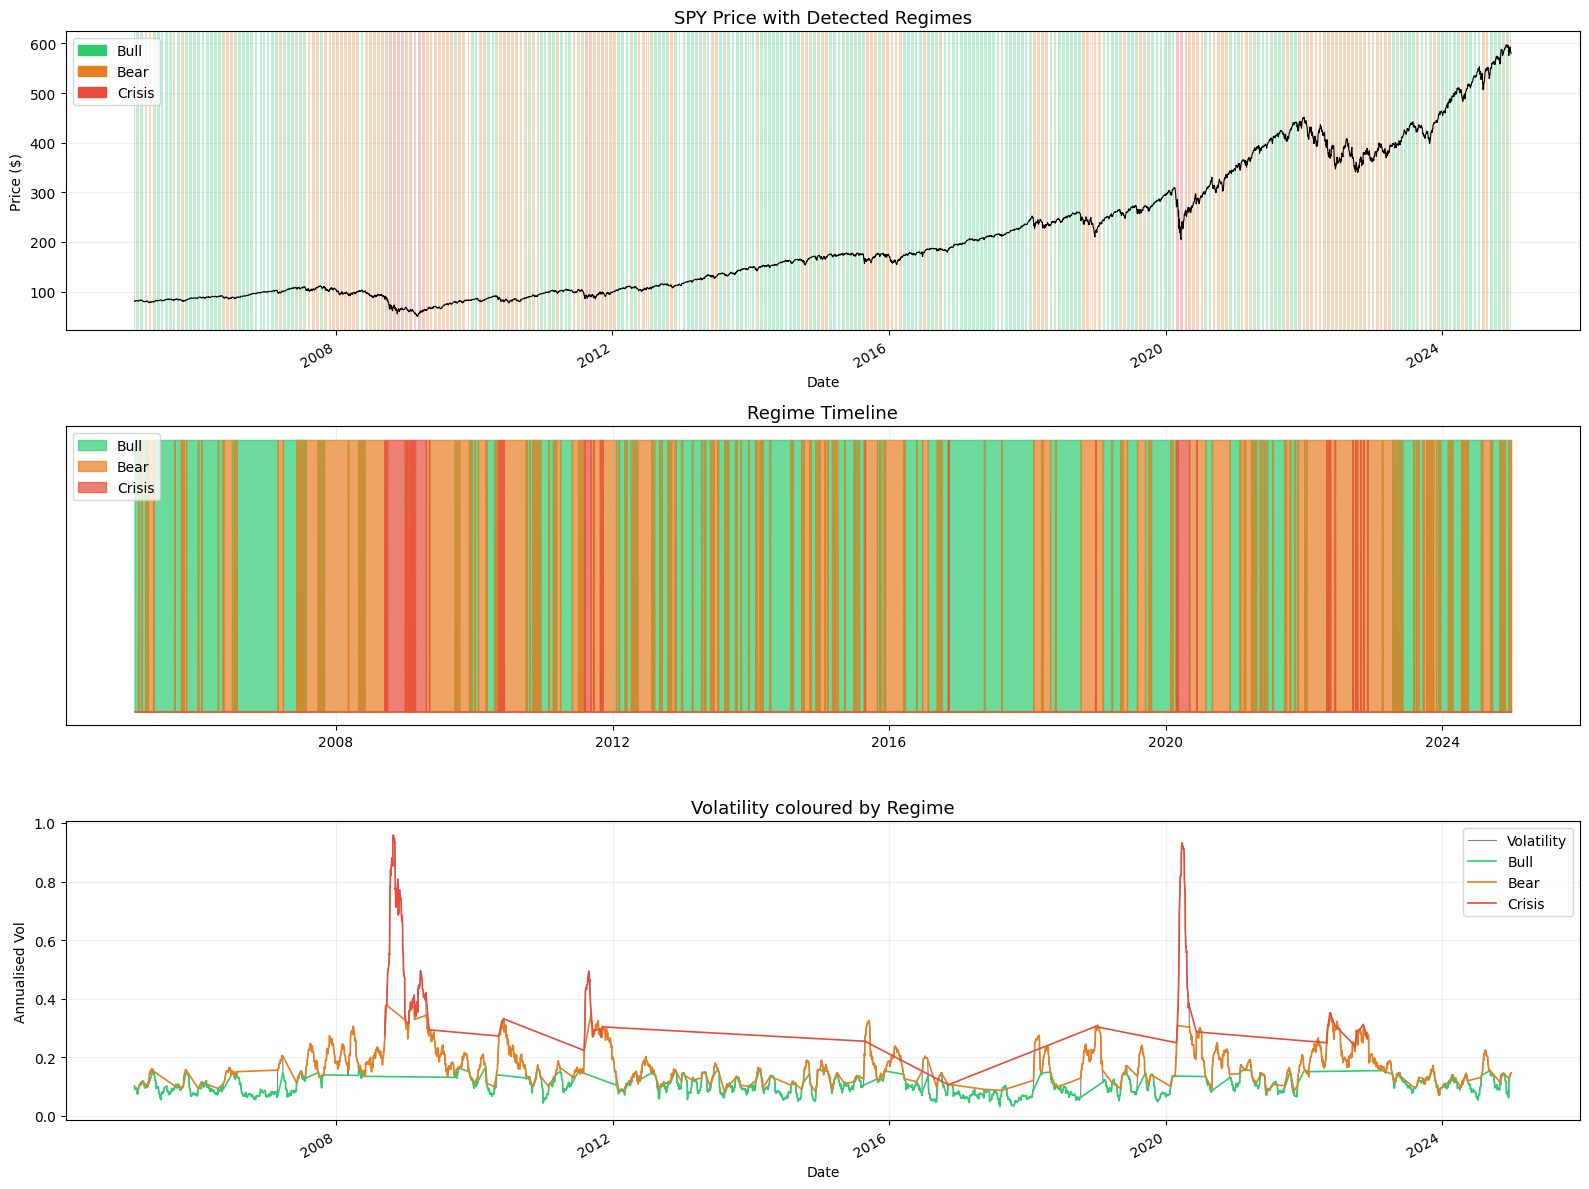


✓ Phase 3 complete! Regime chart saved to outputs/02_regimes.png


In [6]:
# ── Fix: align indices before masking ────────────────────────────────
spy_ret_aligned = spy_ret.reindex(features.index)
vol_20_aligned  = vol_20.reindex(features.index)

print("\n── Regime Statistics ───────────────────────────────────────")
for name in ['Bull', 'Bear', 'Crisis']:
    mask    = regimes == name
    n_days  = mask.sum()
    avg_ret = spy_ret_aligned[mask].mean() * 252 * 100
    avg_vol = vol_20_aligned[mask].mean() * 100
    print(f"  {name:8s}: {n_days:4d} days | Avg annual return: {avg_ret:+.1f}% | Avg vol: {avg_vol:.1f}%")

# ── Plot regimes on price chart ───────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(16, 12))

spy_price = prices['SPY'].reindex(features.index)
ax = axes[0]
for date, regime in regimes.items():
    ax.axvspan(date, date + pd.Timedelta(days=1),
               color=colors_map[regime], alpha=0.3, linewidth=0)
spy_price.plot(ax=ax, color='black', linewidth=0.8)
ax.set_title('SPY Price with Detected Regimes', fontsize=13)
ax.set_ylabel('Price ($)')
ax.grid(alpha=0.2)
patches = [mpatches.Patch(color=colors_map[r], label=r) for r in ['Bull','Bear','Crisis']]
ax.legend(handles=patches, loc='upper left')

regime_num = regimes.map({'Bull': 1, 'Bear': 2, 'Crisis': 3})
ax = axes[1]
for regime, num, color in [('Bull',1,'#2ecc71'),('Bear',2,'#e67e22'),('Crisis',3,'#e74c3c')]:
    mask = regime_num == num
    ax.fill_between(regime_num.index, 0, mask.astype(int),
                    color=color, alpha=0.7, label=regime)
ax.set_title('Regime Timeline', fontsize=13)
ax.set_yticks([])
ax.legend(loc='upper left')
ax.grid(alpha=0.2)

ax = axes[2]
vol_20_aligned.plot(ax=ax, color='gray', linewidth=0.8, label='Volatility')
for regime, color in colors_map.items():
    mask = regimes == regime
    vol_20_aligned[mask].plot(ax=ax, color=color, linewidth=1.2, label=regime)
ax.set_title('Volatility coloured by Regime', fontsize=13)
ax.set_ylabel('Annualised Vol')
ax.legend(loc='upper right')
ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig('../outputs/02_regimes.png', dpi=150)
plt.show()

print("\n✓ Phase 3 complete! Regime chart saved to outputs/02_regimes.png")

── Optimal Weights per Regime ──────────────────────────────

  Bull (objective: sharpe)
    EFA   5.0%  ██
    GLD   5.0%  ██
    IEF   5.0%  ██
    SHY   40.0%  ███████████████
    SPY   40.0%  ███████████████
    TLT   5.0%  ██
    → Expected return: 11.6%  |  Vol: 3.8%  |  Sharpe: 3.03

  Bear (objective: balanced)
    EFA   5.0%  ██
    GLD   12.3%  ████
    IEF   30.5%  ████████████
    SHY   40.0%  ████████████████
    SPY   7.3%  ██
    TLT   5.0%  ██
    → Expected return: 3.6%  |  Vol: 4.8%  |  Sharpe: 0.75

  Crisis (objective: min_vol)
    EFA   5.0%  ██
    GLD   5.0%  ██
    IEF   40.0%  ███████████████
    SHY   40.0%  ███████████████
    SPY   5.0%  ██
    TLT   5.0%  ██
    → Expected return: 10.6%  |  Vol: 8.3%  |  Sharpe: 1.28


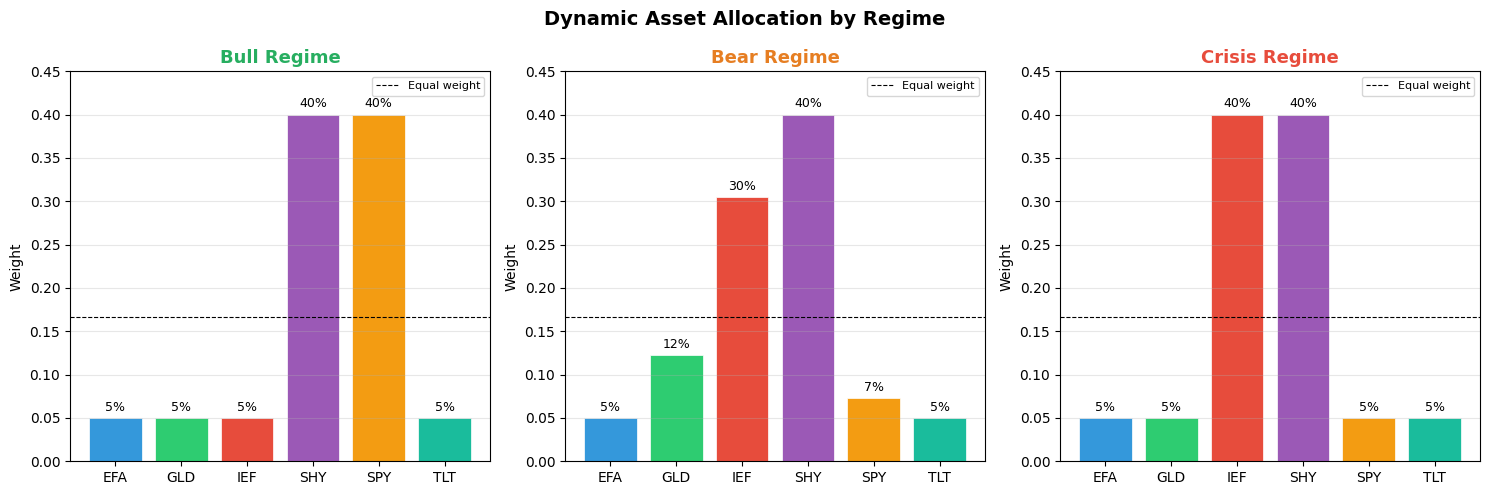


✓ Phase 4 complete! Weights chart saved to outputs/03_regime_weights.png


In [7]:
# ── PHASE 4: Dynamic Portfolio Optimizer ────────────────────────────
# We use scipy.optimize to find the best asset weights per regime.
# "Best" means different things in different regimes.

from scipy.optimize import minimize
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ── Helper functions ─────────────────────────────────────────────────

def portfolio_performance(weights, mean_returns, cov_matrix):
    """Given weights, return (annual_return, annual_volatility, sharpe)"""
    ret = np.dot(weights, mean_returns) * 252
    vol = np.sqrt(weights @ cov_matrix @ weights) * np.sqrt(252)
    sharpe = ret / vol if vol > 0 else 0
    return ret, vol, sharpe

def optimize_portfolio(mean_returns, cov_matrix, objective='sharpe'):
    """
    Find optimal weights.
    objective = 'sharpe'   → maximize Sharpe ratio (Bull regime)
    objective = 'min_vol'  → minimize volatility   (Crisis regime)
    objective = 'balanced' → maximize Sharpe with vol penalty (Bear)
    """
    n = len(mean_returns)
    init_weights = np.ones(n) / n          # start equal
    bounds   = [(0.05, 0.40)] * n          # each asset 5%–40%
    constraints = [{'type': 'eq',
                    'fun': lambda w: np.sum(w) - 1}]  # weights sum to 1

    if objective == 'sharpe':
        def neg_sharpe(w):
            r, v, s = portfolio_performance(w, mean_returns, cov_matrix)
            return -s
        result = minimize(neg_sharpe, init_weights,
                          method='SLSQP', bounds=bounds,
                          constraints=constraints)

    elif objective == 'min_vol':
        def portfolio_vol(w):
            _, v, _ = portfolio_performance(w, mean_returns, cov_matrix)
            return v
        result = minimize(portfolio_vol, init_weights,
                          method='SLSQP', bounds=bounds,
                          constraints=constraints)

    elif objective == 'balanced':
        def neg_balanced(w):
            r, v, s = portfolio_performance(w, mean_returns, cov_matrix)
            return -(s - 0.5 * v)   # reward Sharpe, penalise vol
        result = minimize(neg_balanced, init_weights,
                          method='SLSQP', bounds=bounds,
                          constraints=constraints)

    return result.x

# ── Compute optimal weights for each regime ──────────────────────────
ASSETS = list(returns.columns)
regime_weights = {}
regime_objectives = {'Bull': 'sharpe', 'Bear': 'balanced', 'Crisis': 'min_vol'}

print("── Optimal Weights per Regime ──────────────────────────────")
for regime, objective in regime_objectives.items():
    mask         = regimes == regime
    regime_rets  = returns.reindex(features.index)[mask]

    mean_r = regime_rets.mean()
    cov_m  = regime_rets.cov()

    weights = optimize_portfolio(mean_r.values, cov_m.values, objective)
    regime_weights[regime] = dict(zip(ASSETS, weights))

    ret, vol, sharpe = portfolio_performance(weights, mean_r.values, cov_m.values)
    print(f"\n  {regime} (objective: {objective})")
    for asset, w in zip(ASSETS, weights):
        bar = '█' * int(w * 40)
        print(f"    {asset:4s}  {w:.1%}  {bar}")
    print(f"    → Expected return: {ret*100:.1f}%  |  Vol: {vol*100:.1f}%  |  Sharpe: {sharpe:.2f}")

# ── Bar chart of weights ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors = ['#3498db','#2ecc71','#e74c3c','#9b59b6','#f39c12','#1abc9c']

for ax, (regime, weights_dict) in zip(axes, regime_weights.items()):
    vals = list(weights_dict.values())
    bars = ax.bar(ASSETS, vals, color=colors, edgecolor='white', linewidth=0.5)
    ax.set_title(f'{regime} Regime', fontsize=13, fontweight='bold',
                 color={'Bull':'#27ae60','Bear':'#e67e22','Crisis':'#e74c3c'}[regime])
    ax.set_ylabel('Weight')
    ax.set_ylim(0, 0.45)
    ax.grid(axis='y', alpha=0.3)
    ax.axhline(1/len(ASSETS), color='black', linestyle='--',
               linewidth=0.8, label='Equal weight')
    ax.legend(fontsize=8)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.005,
                f'{val:.0%}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Dynamic Asset Allocation by Regime', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/03_regime_weights.png', dpi=150)
plt.show()

print("\n✓ Phase 4 complete! Weights chart saved to outputs/03_regime_weights.png")

Total days: 5031  |  Training window: 756 days
Backtest starts: 2008-01-07

Running walk-forward backtest...
  2008-01-07  regime=Crisis  portfolio=$1.00  benchmark=$0.99
  2009-01-06  regime=Crisis  portfolio=$1.05  benchmark=$0.88
  2010-01-06  regime=Bull    portfolio=$1.11  benchmark=$0.96
  2011-01-05  regime=Bull    portfolio=$1.20  benchmark=$1.08
  2012-01-05  regime=Bull    portfolio=$1.25  benchmark=$1.25
  2013-01-08  regime=Bull    portfolio=$1.32  benchmark=$1.40
  2014-01-08  regime=Bull    portfolio=$1.39  benchmark=$1.56
  2015-01-08  regime=Crisis  portfolio=$1.46  benchmark=$1.88
  2016-01-08  regime=Crisis  portfolio=$1.43  benchmark=$1.82
  2017-01-09  regime=Bull    portfolio=$1.48  benchmark=$2.06
  2018-01-09  regime=Bull    portfolio=$1.64  benchmark=$2.38
  2019-01-10  regime=Crisis  portfolio=$1.66  benchmark=$2.35
  2020-01-10  regime=Bull    portfolio=$1.76  benchmark=$2.92
  2021-01-11  regime=Bull    portfolio=$1.96  benchmark=$3.45
  2022-01-10  regime=Be

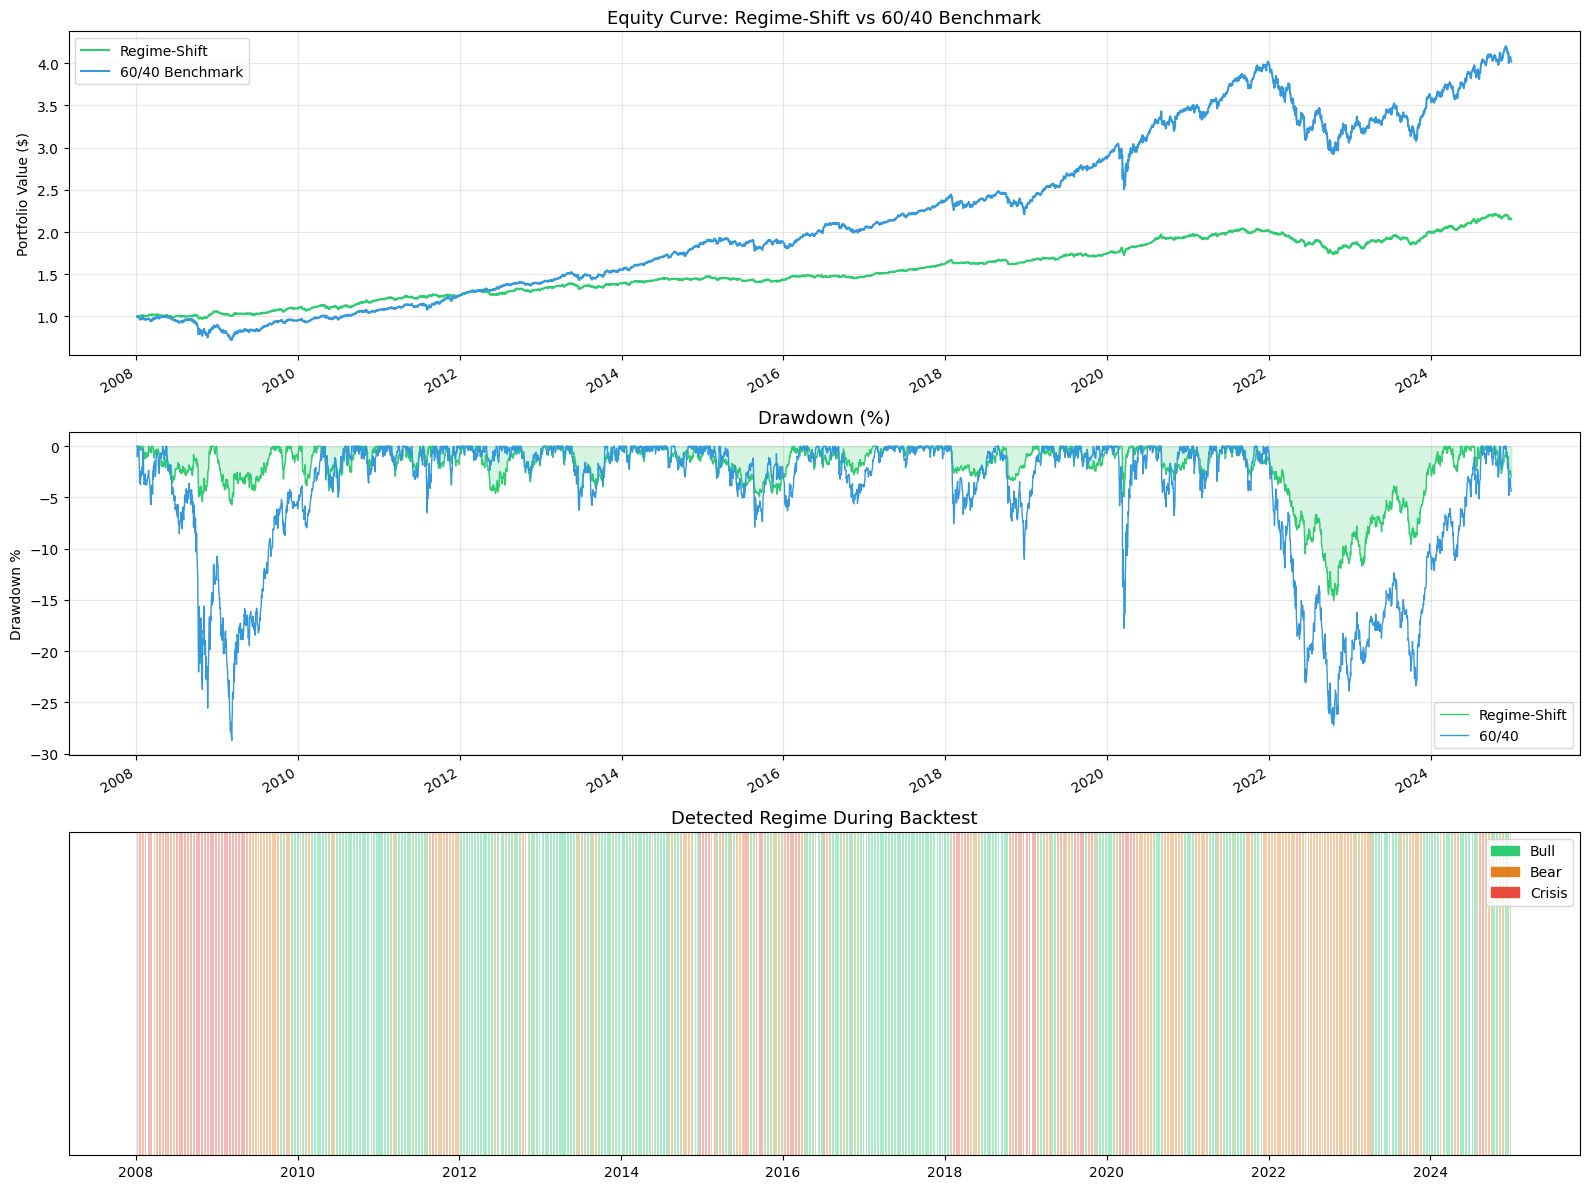


✓ Phase 5 complete! Backtest chart saved to outputs/04_backtest.png


In [8]:
# ── PHASE 5: Walk-Forward Backtester ────────────────────────────────
# Rules:
#   1. Train the regime model only on PAST data (no peeking at future)
#   2. Detect today's regime
#   3. Apply the matching portfolio weights
#   4. Deduct 7 bps (0.07%) transaction cost on every rebalance
#   5. Compare against simple 60/40 benchmark

from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

TRANSACTION_COST = 0.0007   # 7 basis points per rebalance
TRAIN_YEARS      = 3        # use 3 years of history to train
REBAL_FREQ       = 21       # rebalance every ~21 trading days (monthly)

# ── Reload clean data ────────────────────────────────────────────────
prices  = pd.read_csv('../data/prices.csv', index_col=0, parse_dates=True)
returns = pd.read_csv('../data/returns.csv', index_col=0, parse_dates=True)
ASSETS  = list(returns.columns)
dates   = returns.index

TRAIN_DAYS = TRAIN_YEARS * 252
print(f"Total days: {len(dates)}  |  Training window: {TRAIN_DAYS} days")
print(f"Backtest starts: {dates[TRAIN_DAYS].date()}")

# ── Walk-forward loop ────────────────────────────────────────────────
portfolio_values  = [1.0]   # start with $1
benchmark_values  = [1.0]   # 60/40 benchmark
portfolio_dates   = [dates[TRAIN_DAYS]]
regime_history    = []
prev_weights      = None

print("\nRunning walk-forward backtest...")

for i in range(TRAIN_DAYS, len(dates) - 1):

    # ── Step 1: train on past data only ─────────────────────────────
    train_ret = returns.iloc[i - TRAIN_DAYS:i]
    spy_r     = train_ret['SPY']
    tlt_r     = train_ret['TLT']
    vol_20    = spy_r.rolling(20).std() * np.sqrt(252)
    mean_20   = spy_r.rolling(20).mean() * 252

    feats = pd.DataFrame({
        'spy_return': spy_r,
        'volatility': vol_20,
        'trend'     : mean_20,
        'tlt_return': tlt_r,
    }).dropna()

    scaler = StandardScaler()
    X_train = scaler.fit_transform(feats)

    gmm = GaussianMixture(n_components=3, covariance_type='full',
                          n_init=5, random_state=42)
    gmm.fit(X_train)

    # ── Step 2: detect TODAY's regime ───────────────────────────────
    today_feats = feats.iloc[[-1]]
    X_today     = scaler.transform(today_feats)
    raw_label   = gmm.predict(X_today)[0]

    # Map raw label → Bull/Bear/Crisis by volatility rank
    means     = scaler.inverse_transform(gmm.means_)
    vol_idx   = list(feats.columns).index('volatility')
    order     = np.argsort(means[:, vol_idx])
    label_map = {order[0]: 'Bull', order[1]: 'Bear', order[2]: 'Crisis'}
    regime    = label_map[raw_label]
    regime_history.append(regime)

    # ── Step 3: get weights for this regime ─────────────────────────
    # Use pre-computed weights from Phase 4
    weights = np.array([regime_weights[regime][a] for a in ASSETS])

    # ── Step 4: apply transaction cost on rebalance days ────────────
    cost = 0.0
    if prev_weights is not None and (i - TRAIN_DAYS) % REBAL_FREQ == 0:
        turnover = np.sum(np.abs(weights - prev_weights))
        cost     = turnover * TRANSACTION_COST
    prev_weights = weights.copy()

    # ── Step 5: compute next-day portfolio return ────────────────────
    next_day_ret  = returns.iloc[i + 1].values
    port_ret      = np.dot(weights, next_day_ret) - cost
    port_val      = portfolio_values[-1] * (1 + port_ret)
    portfolio_values.append(port_val)
    portfolio_dates.append(dates[i + 1])

    # ── Benchmark: 60% SPY + 40% TLT ────────────────────────────────
    bm_weights = np.array([0.6 if a == 'SPY' else
                           0.4 if a == 'TLT' else 0.0 for a in ASSETS])
    bm_ret     = np.dot(bm_weights, next_day_ret)
    benchmark_values.append(benchmark_values[-1] * (1 + bm_ret))

    # Print progress every year
    if (i - TRAIN_DAYS) % 252 == 0:
        print(f"  {dates[i].date()}  regime={regime:6s}  "
              f"portfolio=${portfolio_values[-1]:.2f}  "
              f"benchmark=${benchmark_values[-1]:.2f}")

print("\n✓ Backtest complete!")

# ── Build results dataframe ──────────────────────────────────────────
results = pd.DataFrame({
    'portfolio' : portfolio_values,
    'benchmark' : benchmark_values,
    'regime'    : [''] + regime_history
}, index=portfolio_dates)

results.to_csv('../outputs/backtest_results.csv')

# ── Performance metrics ──────────────────────────────────────────────
def compute_metrics(series, label):
    daily_ret = series.pct_change().dropna()
    total_ret = (series.iloc[-1] / series.iloc[0] - 1) * 100
    ann_ret   = ((series.iloc[-1] / series.iloc[0]) **
                 (252 / len(daily_ret)) - 1) * 100
    ann_vol   = daily_ret.std() * np.sqrt(252) * 100
    sharpe    = ann_ret / ann_vol
    roll_max  = series.cummax()
    drawdown  = (series - roll_max) / roll_max
    max_dd    = drawdown.min() * 100
    sortino_d = daily_ret[daily_ret < 0].std() * np.sqrt(252) * 100
    sortino   = ann_ret / sortino_d if sortino_d > 0 else 0
    calmar    = ann_ret / abs(max_dd) if max_dd != 0 else 0
    print(f"\n  {label}")
    print(f"    Total return    : {total_ret:+.1f}%")
    print(f"    Annual return   : {ann_ret:+.1f}%")
    print(f"    Annual vol      : {ann_vol:.1f}%")
    print(f"    Sharpe ratio    : {sharpe:.2f}")
    print(f"    Sortino ratio   : {sortino:.2f}")
    print(f"    Calmar ratio    : {calmar:.2f}")
    print(f"    Max drawdown    : {max_dd:.1f}%")
    return dict(total=total_ret, annual=ann_ret, vol=ann_vol,
                sharpe=sharpe, sortino=sortino, calmar=calmar, maxdd=max_dd)

print("\n── Performance Tearsheet ───────────────────────────────────")
m_port = compute_metrics(pd.Series(portfolio_values, index=portfolio_dates), "Regime-Shift Strategy")
m_bm   = compute_metrics(pd.Series(benchmark_values, index=portfolio_dates), "60/40 Benchmark")

# ── Final plot ───────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(16, 12))

# Panel 1: Equity curves
ax = axes[0]
pd.Series(portfolio_values, index=portfolio_dates).plot(
    ax=ax, color='#2ecc71', linewidth=1.5, label='Regime-Shift')
pd.Series(benchmark_values, index=portfolio_dates).plot(
    ax=ax, color='#3498db', linewidth=1.5, label='60/40 Benchmark')
ax.set_title('Equity Curve: Regime-Shift vs 60/40 Benchmark', fontsize=13)
ax.set_ylabel('Portfolio Value ($)')
ax.legend()
ax.grid(alpha=0.3)

# Panel 2: Drawdown
ax = axes[1]
port_s = pd.Series(portfolio_values, index=portfolio_dates)
bm_s   = pd.Series(benchmark_values, index=portfolio_dates)
(((port_s - port_s.cummax()) / port_s.cummax()) * 100).plot(
    ax=ax, color='#2ecc71', linewidth=1, label='Regime-Shift')
(((bm_s - bm_s.cummax()) / bm_s.cummax()) * 100).plot(
    ax=ax, color='#3498db', linewidth=1, label='60/40')
ax.fill_between(port_s.index,
                ((port_s - port_s.cummax()) / port_s.cummax()) * 100,
                0, color='#2ecc71', alpha=0.2)
ax.set_title('Drawdown (%)', fontsize=13)
ax.set_ylabel('Drawdown %')
ax.legend()
ax.grid(alpha=0.3)

# Panel 3: Regime over time
ax = axes[2]
reg_series = pd.Series([''] + regime_history, index=portfolio_dates)
colors_map = {'Bull': '#2ecc71', 'Bear': '#e67e22', 'Crisis': '#e74c3c', '': 'white'}
for date, regime in reg_series.items():
    if regime:
        ax.axvspan(date, date + pd.Timedelta(days=1),
                   color=colors_map[regime], alpha=0.4, linewidth=0)
ax.set_title('Detected Regime During Backtest', fontsize=13)
ax.set_yticks([])
patches = [mpatches.Patch(color=colors_map[r], label=r)
           for r in ['Bull', 'Bear', 'Crisis']]
ax.legend(handles=patches)
ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig('../outputs/04_backtest.png', dpi=150)
plt.show()
print("\n✓ Phase 5 complete! Backtest chart saved to outputs/04_backtest.png")

ValueError: 'transform' is not allowed as a keyword argument; axhline generates its own transform.

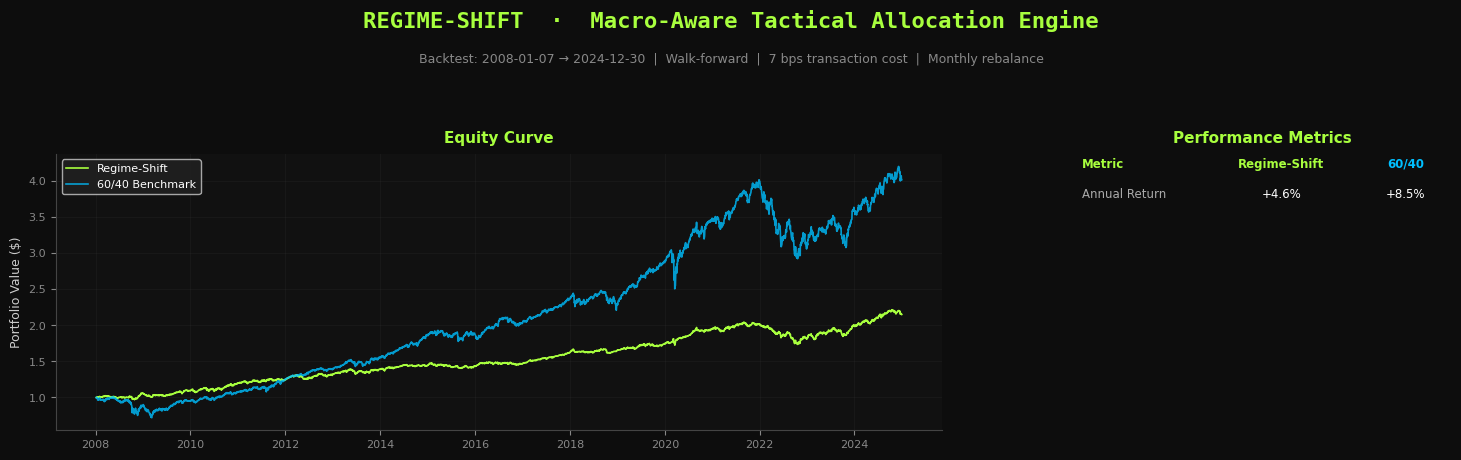

In [9]:
# ── PHASE 6: Professional Tearsheet ─────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
import numpy as np

# ── Load backtest results ────────────────────────────────────────────
results = pd.read_csv('../outputs/backtest_results.csv', index_col=0, parse_dates=True)
port    = results['portfolio']
bm      = results['benchmark']

# ── Metric helpers ───────────────────────────────────────────────────
def metrics(s):
    dr      = s.pct_change().dropna()
    ann_r   = ((s.iloc[-1]/s.iloc[0])**(252/len(dr))-1)*100
    ann_v   = dr.std()*np.sqrt(252)*100
    sharpe  = ann_r/ann_v
    dd      = (s - s.cummax())/s.cummax()*100
    maxdd   = dd.min()
    sortino = ann_r/(dr[dr<0].std()*np.sqrt(252)*100)
    calmar  = ann_r/abs(maxdd)
    wr      = (dr>0).mean()*100
    return dict(ann_r=ann_r, ann_v=ann_v, sharpe=sharpe,
                maxdd=maxdd, sortino=sortino, calmar=calmar, wr=wr)

mp = metrics(port)
mb = metrics(bm)

# ── Build tearsheet ──────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 14), facecolor='#0d0d0d')
gs  = gridspec.GridSpec(3, 3, figure=fig,
                         hspace=0.45, wspace=0.35)

title_kw  = dict(color='#a8ff3e', fontsize=11, fontweight='bold', pad=8)
label_kw  = dict(color='#cccccc', fontsize=9)
tick_kw   = dict(colors='#888888', labelsize=8)
GREEN     = '#a8ff3e'
BLUE      = '#00bfff'
RED       = '#ff4444'
GRAY      = '#444444'

fig.text(0.5, 0.97, 'REGIME-SHIFT  ·  Macro-Aware Tactical Allocation Engine',
         ha='center', fontsize=16, fontweight='bold', color=GREEN,
         fontfamily='monospace')
fig.text(0.5, 0.945, f'Backtest: {port.index[0].date()} → {port.index[-1].date()}  '
         f'|  Walk-forward  |  7 bps transaction cost  |  Monthly rebalance',
         ha='center', fontsize=9, color='#888888')

# ── Panel 1: Equity curve ────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :2])
ax1.plot(port.index, port, color=GREEN,  linewidth=1.2, label='Regime-Shift')
ax1.plot(bm.index,   bm,   color=BLUE,   linewidth=1.2, label='60/40 Benchmark', alpha=0.8)
ax1.set_facecolor('#111111')
ax1.set_title('Equity Curve', **title_kw)
ax1.set_ylabel('Portfolio Value ($)', **label_kw)
ax1.legend(fontsize=8, facecolor='#222222', labelcolor='white')
ax1.grid(alpha=0.15, color=GRAY)
ax1.tick_params(axis='both', **tick_kw)
ax1.spines['bottom'].set_color(GRAY)
ax1.spines['left'].set_color(GRAY)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# ── Panel 2: Metrics table ───────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 2])
ax2.set_facecolor('#111111')
ax2.set_title('Performance Metrics', **title_kw)
ax2.axis('off')

rows = [
    ('Metric',           'Regime-Shift',        '60/40'),
    ('Annual Return',    f"{mp['ann_r']:+.1f}%", f"{mb['ann_r']:+.1f}%"),
    ('Annual Vol',       f"{mp['ann_v']:.1f}%",  f"{mb['ann_v']:.1f}%"),
    ('Sharpe Ratio',     f"{mp['sharpe']:.2f}",  f"{mb['sharpe']:.2f}"),
    ('Sortino Ratio',    f"{mp['sortino']:.2f}",  f"{mb['sortino']:.2f}"),
    ('Calmar Ratio',     f"{mp['calmar']:.2f}",  f"{mb['calmar']:.2f}"),
    ('Max Drawdown',     f"{mp['maxdd']:.1f}%",  f"{mb['maxdd']:.1f}%"),
    ('Win Rate',         f"{mp['wr']:.1f}%",     f"{mb['wr']:.1f}%"),
]

for i, (label, val_p, val_b) in enumerate(rows):
    y = 0.95 - i * 0.11
    is_header = i == 0
    color_l = GREEN if is_header else '#aaaaaa'
    color_p = GREEN if is_header else 'white'
    color_b = BLUE  if is_header else 'white'
    fw = 'bold' if is_header else 'normal'
    ax2.text(0.02, y, label,  transform=ax2.transAxes,
             color=color_l, fontsize=8.5, fontweight=fw)
    ax2.text(0.55, y, val_p,  transform=ax2.transAxes,
             color=color_p, fontsize=8.5, fontweight=fw, ha='center')
    ax2.text(0.88, y, val_b,  transform=ax2.transAxes,
             color=color_b, fontsize=8.5, fontweight=fw, ha='center')
    if not is_header:
        ax2.axhline(y - 0.04, color=GRAY, linewidth=0.4,
                    xmin=0.0, xmax=1.0, transform=ax2.transAxes)

# ── Panel 3: Drawdown ────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, :2])
dd_p = (port - port.cummax()) / port.cummax() * 100
dd_b = (bm   - bm.cummax())   / bm.cummax()   * 100
ax3.fill_between(port.index, dd_p, 0, color=GREEN, alpha=0.3)
ax3.fill_between(bm.index,   dd_b, 0, color=BLUE,  alpha=0.2)
ax3.plot(port.index, dd_p, color=GREEN, linewidth=0.8)
ax3.plot(bm.index,   dd_b, color=BLUE,  linewidth=0.8)
ax3.set_facecolor('#111111')
ax3.set_title('Drawdown (%)', **title_kw)
ax3.set_ylabel('Drawdown %', **label_kw)
ax3.grid(alpha=0.15, color=GRAY)
ax3.tick_params(axis='both', **tick_kw)
for sp in ['top','right']: ax3.spines[sp].set_visible(False)
for sp in ['bottom','left']: ax3.spines[sp].set_color(GRAY)

# ── Panel 4: Monthly returns heatmap ────────────────────────────────
ax4 = fig.add_subplot(gs[1, 2])
ax4.set_facecolor('#111111')
ax4.set_title('Monthly Returns (Strategy)', **title_kw)
monthly = port.resample('ME').last().pct_change().dropna() * 100
monthly_df = monthly.to_frame('ret')
monthly_df['year']  = monthly_df.index.year
monthly_df['month'] = monthly_df.index.month
pivot = monthly_df.pivot_table(values='ret', index='year', columns='month')
pivot.columns = ['J','F','M','A','M','J','J','A','S','O','N','D']
im = ax4.imshow(pivot.values, aspect='auto', cmap='RdYlGn', vmin=-5, vmax=5)
ax4.set_xticks(range(12))
ax4.set_xticklabels(pivot.columns, fontsize=7, color='#aaaaaa')
ax4.set_yticks(range(len(pivot.index)))
ax4.set_yticklabels(pivot.index, fontsize=7, color='#aaaaaa')
ax4.tick_params(length=0)
for sp in ax4.spines.values(): sp.set_visible(False)

# ── Panel 5: Rolling Sharpe ──────────────────────────────────────────
ax5 = fig.add_subplot(gs[2, :2])
roll_ret = port.pct_change().dropna()
roll_sharpe = (roll_ret.rolling(252).mean() *252) / (roll_ret.rolling(252).std()*np.sqrt(252))
roll_sharpe.plot(ax=ax5, color=GREEN, linewidth=1)
ax5.axhline(0, color=RED,  linewidth=0.8, linestyle='--')
ax5.axhline(1, color=GRAY, linewidth=0.8, linestyle='--', alpha=0.5)
ax5.fill_between(roll_sharpe.index, roll_sharpe, 0,
                 where=roll_sharpe > 0, color=GREEN, alpha=0.2)
ax5.fill_between(roll_sharpe.index, roll_sharpe, 0,
                 where=roll_sharpe < 0, color=RED,   alpha=0.2)
ax5.set_facecolor('#111111')
ax5.set_title('Rolling 1-Year Sharpe Ratio', **title_kw)
ax5.set_ylabel('Sharpe', **label_kw)
ax5.grid(alpha=0.15, color=GRAY)
ax5.tick_params(axis='both', **tick_kw)
for sp in ['top','right']: ax5.spines[sp].set_visible(False)
for sp in ['bottom','left']: ax5.spines[sp].set_color(GRAY)

# ── Panel 6: Regime distribution ────────────────────────────────────
ax6 = fig.add_subplot(gs[2, 2])
ax6.set_facecolor('#111111')
ax6.set_title('Regime Distribution', **title_kw)
reg = results['regime'].replace('', np.nan).dropna()
counts = reg.value_counts()
colors_pie = [{'Bull':'#a8ff3e','Bear':'#e67e22','Crisis':'#ff4444'}.get(r,'gray')
              for r in counts.index]
wedges, texts, autotexts = ax6.pie(
    counts.values, labels=counts.index,
    colors=colors_pie, autopct='%1.0f%%',
    textprops=dict(color='white', fontsize=9),
    wedgeprops=dict(linewidth=0.5, edgecolor='#222222'))
for at in autotexts: at.set_color('#111111')

plt.savefig('../outputs/05_tearsheet.png', dpi=150, bbox_inches='tight',
            facecolor='#0d0d0d')
plt.show()
print("\n✓ Phase 6 complete!")
print("✓ Tearsheet saved to outputs/05_tearsheet.png")
print("\n🎉 REGIME-SHIFT PROJECT COMPLETE!")
print("   Check your outputs/ folder for all 5 charts.")

In [10]:
# ── Fix: replace axhline with a line drawn in axes coordinates ───────
for i, (label, val_p, val_b) in enumerate(rows):
    y = 0.95 - i * 0.11
    is_header = i == 0
    color_l = GREEN if is_header else '#aaaaaa'
    color_p = GREEN if is_header else 'white'
    color_b = BLUE  if is_header else 'white'
    fw = 'bold' if is_header else 'normal'
    ax2.text(0.02, y, label,  transform=ax2.transAxes,
             color=color_l, fontsize=8.5, fontweight=fw)
    ax2.text(0.55, y, val_p,  transform=ax2.transAxes,
             color=color_p, fontsize=8.5, fontweight=fw, ha='center')
    ax2.text(0.88, y, val_b,  transform=ax2.transAxes,
             color=color_b, fontsize=8.5, fontweight=fw, ha='center')
    if not is_header:
        line = plt.Line2D([0, 1], [y - 0.04, y - 0.04],
                          transform=ax2.transAxes,
                          color=GRAY, linewidth=0.4)
        ax2.add_line(line)

plt.savefig('../outputs/05_tearsheet.png', dpi=150, bbox_inches='tight',
            facecolor='#0d0d0d')
plt.show()
print("✓ Tearsheet saved!")

<Figure size 640x480 with 0 Axes>

✓ Tearsheet saved!


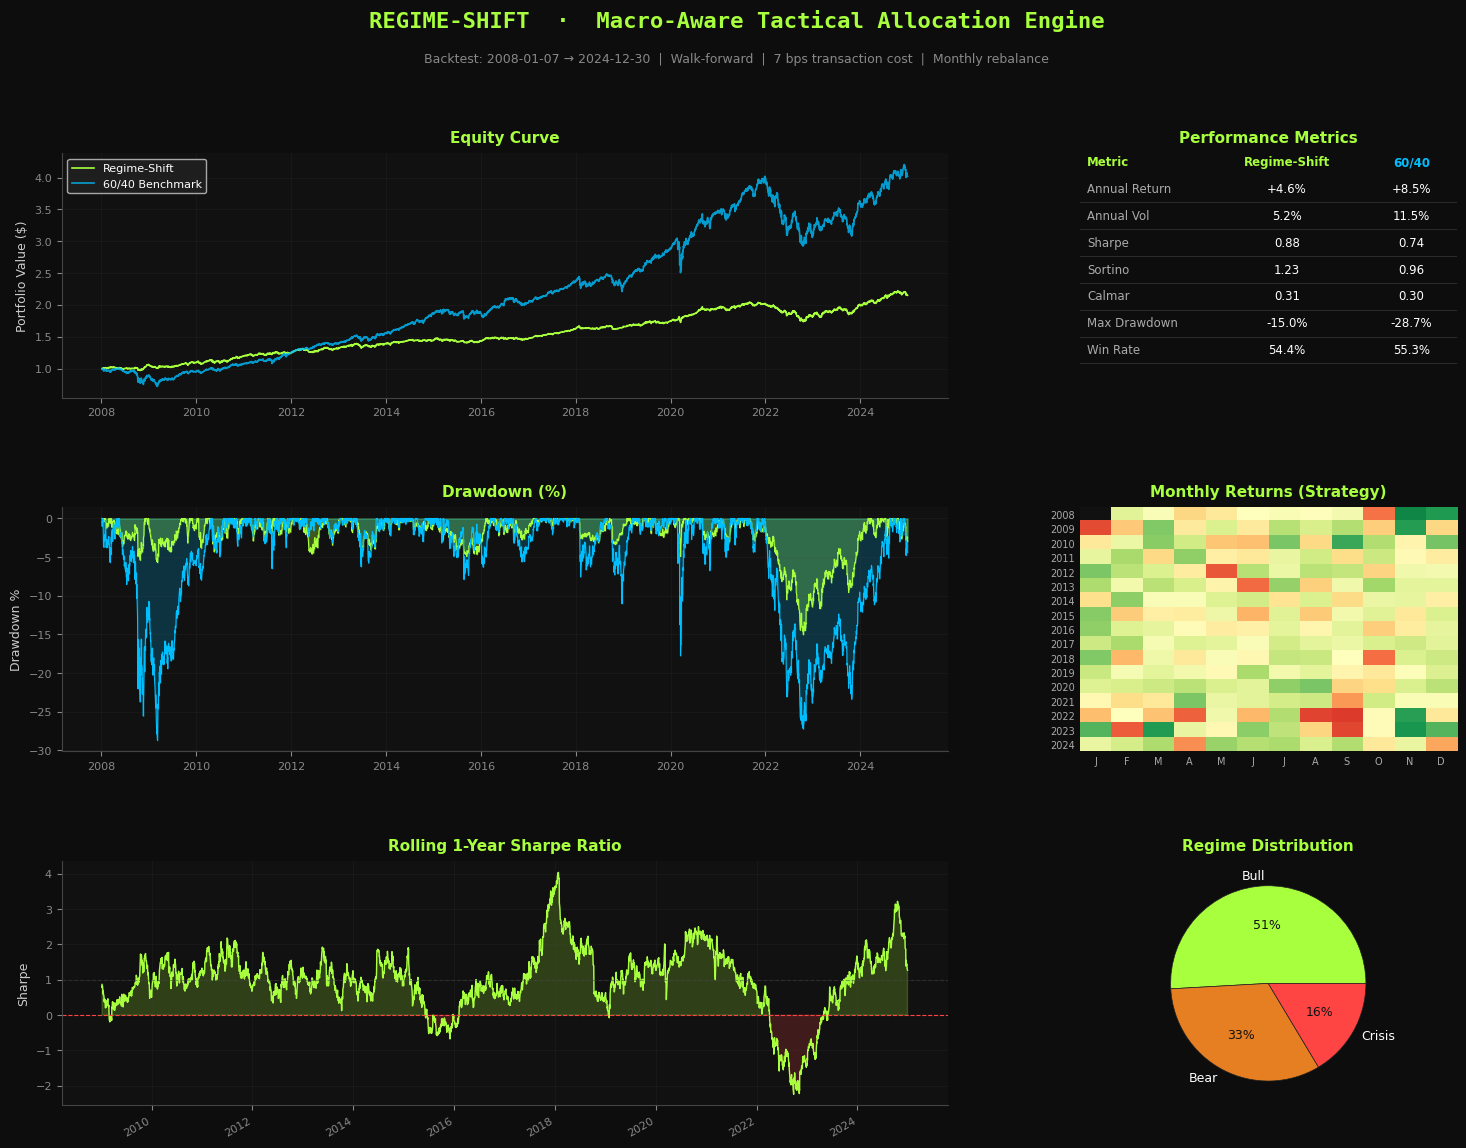

✓ Tearsheet saved to outputs/05_tearsheet.png

🎉 REGIME-SHIFT PROJECT COMPLETE!
   All outputs saved to the outputs/ folder.


In [11]:
# ── PHASE 6: Professional Tearsheet (fixed) ─────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.lines as mlines
import pandas as pd
import numpy as np

results = pd.read_csv('../outputs/backtest_results.csv', index_col=0, parse_dates=True)
port    = results['portfolio']
bm      = results['benchmark']

def metrics(s):
    dr      = s.pct_change().dropna()
    ann_r   = ((s.iloc[-1]/s.iloc[0])**(252/len(dr))-1)*100
    ann_v   = dr.std()*np.sqrt(252)*100
    sharpe  = ann_r/ann_v
    dd      = (s - s.cummax())/s.cummax()*100
    maxdd   = dd.min()
    sortino = ann_r/(dr[dr<0].std()*np.sqrt(252)*100)
    calmar  = ann_r/abs(maxdd)
    wr      = (dr>0).mean()*100
    return dict(ann_r=ann_r, ann_v=ann_v, sharpe=sharpe,
                maxdd=maxdd, sortino=sortino, calmar=calmar, wr=wr)

mp = metrics(port)
mb = metrics(bm)

GREEN = '#a8ff3e'
BLUE  = '#00bfff'
RED   = '#ff4444'
GRAY  = '#444444'

fig = plt.figure(figsize=(18, 14), facecolor='#0d0d0d')
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

title_kw = dict(color=GREEN, fontsize=11, fontweight='bold', pad=8)
label_kw = dict(color='#cccccc', fontsize=9)
tick_kw  = dict(colors='#888888', labelsize=8)

fig.text(0.5, 0.97,
         'REGIME-SHIFT  ·  Macro-Aware Tactical Allocation Engine',
         ha='center', fontsize=16, fontweight='bold',
         color=GREEN, fontfamily='monospace')
fig.text(0.5, 0.945,
         f'Backtest: {port.index[0].date()} → {port.index[-1].date()}'
         f'  |  Walk-forward  |  7 bps transaction cost  |  Monthly rebalance',
         ha='center', fontsize=9, color='#888888')

# ── Equity curve ─────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :2])
ax1.plot(port.index, port, color=GREEN, linewidth=1.2, label='Regime-Shift')
ax1.plot(bm.index,   bm,   color=BLUE,  linewidth=1.2, label='60/40 Benchmark', alpha=0.8)
ax1.set_facecolor('#111111')
ax1.set_title('Equity Curve', **title_kw)
ax1.set_ylabel('Portfolio Value ($)', **label_kw)
ax1.legend(fontsize=8, facecolor='#222222', labelcolor='white')
ax1.grid(alpha=0.15, color=GRAY)
ax1.tick_params(axis='both', **tick_kw)
for sp in ['top','right']: ax1.spines[sp].set_visible(False)
for sp in ['bottom','left']: ax1.spines[sp].set_color(GRAY)

# ── Metrics table ─────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 2])
ax2.set_facecolor('#111111')
ax2.set_title('Performance Metrics', **title_kw)
ax2.axis('off')

rows = [
    ('Metric',        'Regime-Shift',         '60/40'),
    ('Annual Return', f"{mp['ann_r']:+.1f}%",  f"{mb['ann_r']:+.1f}%"),
    ('Annual Vol',    f"{mp['ann_v']:.1f}%",   f"{mb['ann_v']:.1f}%"),
    ('Sharpe',        f"{mp['sharpe']:.2f}",   f"{mb['sharpe']:.2f}"),
    ('Sortino',       f"{mp['sortino']:.2f}",  f"{mb['sortino']:.2f}"),
    ('Calmar',        f"{mp['calmar']:.2f}",   f"{mb['calmar']:.2f}"),
    ('Max Drawdown',  f"{mp['maxdd']:.1f}%",   f"{mb['maxdd']:.1f}%"),
    ('Win Rate',      f"{mp['wr']:.1f}%",      f"{mb['wr']:.1f}%"),
]

for i, (label, val_p, val_b) in enumerate(rows):
    y  = 0.95 - i * 0.11
    is_header = i == 0
    cl = GREEN if is_header else '#aaaaaa'
    cp = GREEN if is_header else 'white'
    cb = BLUE  if is_header else 'white'
    fw = 'bold' if is_header else 'normal'
    ax2.text(0.02, y, label,  transform=ax2.transAxes, color=cl, fontsize=8.5, fontweight=fw)
    ax2.text(0.55, y, val_p,  transform=ax2.transAxes, color=cp, fontsize=8.5, fontweight=fw, ha='center')
    ax2.text(0.88, y, val_b,  transform=ax2.transAxes, color=cb, fontsize=8.5, fontweight=fw, ha='center')
    if not is_header:
        ax2.add_line(mlines.Line2D([0, 1], [y-0.04, y-0.04],
                     transform=ax2.transAxes, color=GRAY, linewidth=0.4))

# ── Drawdown ──────────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, :2])
dd_p = (port - port.cummax()) / port.cummax() * 100
dd_b = (bm   - bm.cummax())   / bm.cummax()   * 100
ax3.fill_between(port.index, dd_p, 0, color=GREEN, alpha=0.3)
ax3.fill_between(bm.index,   dd_b, 0, color=BLUE,  alpha=0.2)
ax3.plot(port.index, dd_p, color=GREEN, linewidth=0.8)
ax3.plot(bm.index,   dd_b, color=BLUE,  linewidth=0.8)
ax3.set_facecolor('#111111')
ax3.set_title('Drawdown (%)', **title_kw)
ax3.set_ylabel('Drawdown %', **label_kw)
ax3.grid(alpha=0.15, color=GRAY)
ax3.tick_params(axis='both', **tick_kw)
for sp in ['top','right']: ax3.spines[sp].set_visible(False)
for sp in ['bottom','left']: ax3.spines[sp].set_color(GRAY)

# ── Monthly heatmap ───────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 2])
ax4.set_facecolor('#111111')
ax4.set_title('Monthly Returns (Strategy)', **title_kw)
monthly    = port.resample('ME').last().pct_change().dropna() * 100
monthly_df = monthly.to_frame('ret')
monthly_df['year']  = monthly_df.index.year
monthly_df['month'] = monthly_df.index.month
pivot = monthly_df.pivot_table(values='ret', index='year', columns='month')
pivot.columns = ['J','F','M','A','M','J','J','A','S','O','N','D']
ax4.imshow(pivot.values, aspect='auto', cmap='RdYlGn', vmin=-5, vmax=5)
ax4.set_xticks(range(12))
ax4.set_xticklabels(pivot.columns, fontsize=7, color='#aaaaaa')
ax4.set_yticks(range(len(pivot.index)))
ax4.set_yticklabels(pivot.index, fontsize=7, color='#aaaaaa')
ax4.tick_params(length=0)
for sp in ax4.spines.values(): sp.set_visible(False)

# ── Rolling Sharpe ────────────────────────────────────────────────────
ax5 = fig.add_subplot(gs[2, :2])
dr  = port.pct_change().dropna()
rs  = (dr.rolling(252).mean()*252) / (dr.rolling(252).std()*np.sqrt(252))
rs.plot(ax=ax5, color=GREEN, linewidth=1)
ax5.axhline(0, color=RED,  linewidth=0.8, linestyle='--')
ax5.axhline(1, color=GRAY, linewidth=0.8, linestyle='--', alpha=0.5)
ax5.fill_between(rs.index, rs, 0, where=rs>0, color=GREEN, alpha=0.2)
ax5.fill_between(rs.index, rs, 0, where=rs<0, color=RED,   alpha=0.2)
ax5.set_facecolor('#111111')
ax5.set_title('Rolling 1-Year Sharpe Ratio', **title_kw)
ax5.set_ylabel('Sharpe', **label_kw)
ax5.grid(alpha=0.15, color=GRAY)
ax5.tick_params(axis='both', **tick_kw)
for sp in ['top','right']: ax5.spines[sp].set_visible(False)
for sp in ['bottom','left']: ax5.spines[sp].set_color(GRAY)

# ── Regime pie ────────────────────────────────────────────────────────
ax6 = fig.add_subplot(gs[2, 2])
ax6.set_facecolor('#111111')
ax6.set_title('Regime Distribution', **title_kw)
reg    = results['regime'].replace('', np.nan).dropna()
counts = reg.value_counts()
cpie   = [{'Bull': GREEN, 'Bear':'#e67e22', 'Crisis': RED}.get(r,'gray')
          for r in counts.index]
wedges, texts, autotexts = ax6.pie(
    counts.values, labels=counts.index, colors=cpie,
    autopct='%1.0f%%',
    textprops=dict(color='white', fontsize=9),
    wedgeprops=dict(linewidth=0.5, edgecolor='#222222'))
for at in autotexts: at.set_color('#111111')

plt.savefig('../outputs/05_tearsheet.png', dpi=150,
            bbox_inches='tight', facecolor='#0d0d0d')
plt.show()
print("✓ Tearsheet saved to outputs/05_tearsheet.png")
print("\n🎉 REGIME-SHIFT PROJECT COMPLETE!")
print("   All outputs saved to the outputs/ folder.")

In [12]:
import os
import shutil

# Search entire user folder for our files
target_files = [
    '01_prices_and_vol.png',
    '02_regimes.png', 
    '03_regime_weights.png',
    '04_backtest.png',
    '05_tearsheet.png',
    'backtest_results.csv',
    'prices.csv',
    'returns.csv'
]

print("Searching for files...")
found = {}
for root, dirs, files in os.walk('C:\\Users\\anves'):
    for file in files:
        if file in target_files:
            full_path = os.path.join(root, file)
            found[file] = full_path
            print(f"  ✓ Found: {full_path}")

print(f"\nFound {len(found)} files")

# Now copy them to the correct folders
outputs_dir = 'C:\\Users\\anves\\regime-shift\\outputs'
data_dir    = 'C:\\Users\\anves\\regime-shift\\data'
os.makedirs(outputs_dir, exist_ok=True)
os.makedirs(data_dir, exist_ok=True)

for filename, src_path in found.items():
    if filename.endswith('.png') or filename == 'backtest_results.csv':
        dst = os.path.join(outputs_dir, filename)
    else:
        dst = os.path.join(data_dir, filename)
    shutil.copy2(src_path, dst)
    print(f"  → Copied {filename} to correct folder")

print("\n✓ Done! Check your outputs/ and data/ folders now.")

Searching for files...
  ✓ Found: C:\Users\anves\data\prices.csv
  ✓ Found: C:\Users\anves\data\returns.csv
  ✓ Found: C:\Users\anves\outputs\01_prices_and_vol.png
  ✓ Found: C:\Users\anves\outputs\02_regimes.png
  ✓ Found: C:\Users\anves\outputs\03_regime_weights.png
  ✓ Found: C:\Users\anves\outputs\04_backtest.png
  ✓ Found: C:\Users\anves\outputs\05_tearsheet.png
  ✓ Found: C:\Users\anves\outputs\backtest_results.csv

Found 8 files
  → Copied prices.csv to correct folder
  → Copied returns.csv to correct folder
  → Copied 01_prices_and_vol.png to correct folder
  → Copied 02_regimes.png to correct folder
  → Copied 03_regime_weights.png to correct folder
  → Copied 04_backtest.png to correct folder
  → Copied 05_tearsheet.png to correct folder
  → Copied backtest_results.csv to correct folder

✓ Done! Check your outputs/ and data/ folders now.


In [13]:
import os

for root, dirs, files in os.walk('C:\\Users\\anves'):
    for file in files:
        if file.endswith('.ipynb'):
            print(os.path.join(root, file))

C:\Users\anves\04_scipython__code.ipynb
C:\Users\anves\.ipynb_checkpoints\04_scipython__code-checkpoint.ipynb
C:\Users\anves\.vscode\extensions\ms-python.python-2026.4.0-win32-x64\python_files\Notebooks intro.ipynb
C:\Users\anves\anaconda3\Lib\site-packages\datashader\examples\FAQ.ipynb
C:\Users\anves\anaconda3\Lib\site-packages\datashader\examples\index.ipynb
C:\Users\anves\anaconda3\Lib\site-packages\datashader\examples\tiling.ipynb
C:\Users\anves\anaconda3\Lib\site-packages\datashader\examples\getting_started\1_Introduction.ipynb
C:\Users\anves\anaconda3\Lib\site-packages\datashader\examples\getting_started\2_Pipeline.ipynb
C:\Users\anves\anaconda3\Lib\site-packages\datashader\examples\getting_started\3_Interactivity.ipynb
C:\Users\anves\anaconda3\Lib\site-packages\datashader\examples\getting_started\index.ipynb
C:\Users\anves\anaconda3\Lib\site-packages\datashader\examples\user_guide\10_Performance.ipynb
C:\Users\anves\anaconda3\Lib\site-packages\datashader\examples\user_guide\11_G